<a href="https://colab.research.google.com/github/NehaMusale11/Machine-Vision/blob/main/Practical_09_MachineV_CM23057_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get update -qq
!apt-get install -y tesseract-ocr
!pip install -q kagglehub pytesseract opencv-python matplotlib pandas

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "senju14/ocr-dataset-of-multi-type-documents"
)

print("Path to dataset files:", path)

100%|██████████| 5.16G/5.16G [01:20<00:00, 69.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3


In [3]:
import os

print("Dataset Path:")
print(path)

print("\nDataset structure:\n")

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)

    if level <= 3:
        indent = "  " * level
        print(indent + os.path.basename(root) + "/")

        for file in files[:10]:
            print(indent + "  " + file)

Dataset Path:
/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3

Dataset structure:

3/
  document/
    train/
      annotations/
        g04-081.json
        a06-152.json
        d06-011.json
        d04-062.json
        g04-072.json
        b06-027.json
        c06-052.json
        b03-092.json
        c02-026.json
        c06-106.json
      images/
        n04-130.png
        a05-013.png
        g06-050d.png
        h07-040b.png
        b06-068.png
        d06-104.png
        l01-023.png
        m03-020.png
        d04-032.png
        f04-068.png
    val/
      annotations/
        b01-027.json
        c04-028.json
        c03-021d.json
        n02-062.json
        c04-061.json
        c02-003.json
        e02-074.json
        c02-056.json
        f07-101b.json
        m06-083.json
      images/
        a01-122u.png
        b04-195.png
        g06-045i.png
        n02-037.png
        f07-092a.png
        p03-142.png
        h04-074.png
        f0

In [4]:
import glob
import os

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]

image_files = []

for ext in image_extensions:
    image_files.extend(
        glob.glob(
            os.path.join(path, "**", ext),
            recursive=True
        )
    )

print("Total images found:", len(image_files))

print("\nFirst 10 images:")

for img in image_files[:10]:
    print(img)

Total images found: 4265

First 10 images:
/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/real_life/train/images/img119.jpg
/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/real_life/train/images/img959.jpg
/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/real_life/train/images/img141.jpg
/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/real_life/train/images/img1027.jpg
/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/real_life/train/images/img1184.jpg
/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/real_life/train/images/img1440.jpg
/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/real_life/train/images/img1336.jpg
/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/real_life/train/ima

In [5]:
import cv2
import matplotlib.pyplot as plt

image_path = image_files[0]

image = cv2.imread(image_path)

print("Image:", image_path)
print("Shape:", image.shape)

Image: /root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/real_life/train/images/img119.jpg
Shape: (460, 600, 3)


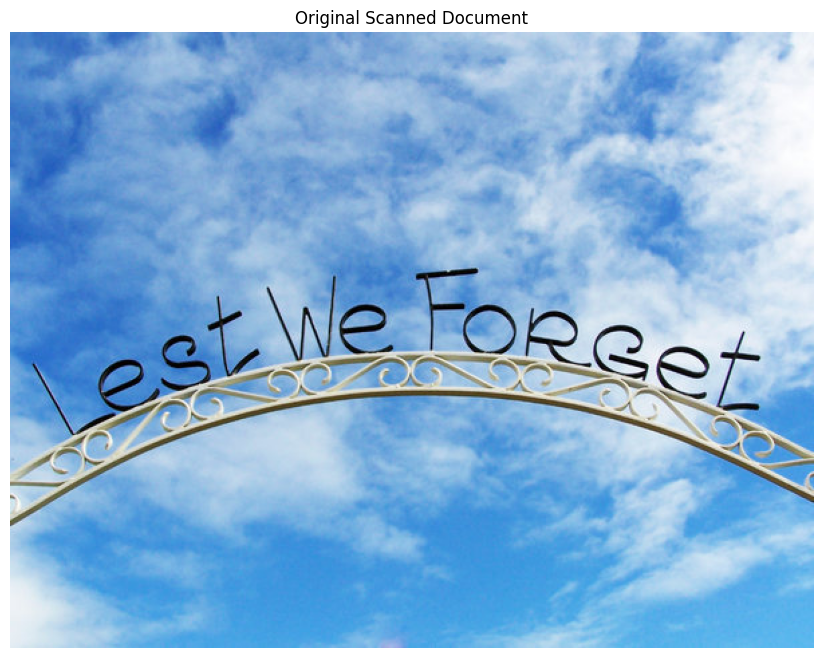

In [6]:
plt.figure(figsize=(12, 8))

plt.imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.title("Original Scanned Document")

plt.show()

In [7]:
gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

In [8]:
denoised = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

In [9]:
threshold = cv2.adaptiveThreshold(
    denoised,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

In [10]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (2, 2)
)

processed = cv2.morphologyEx(
    threshold,
    cv2.MORPH_OPEN,
    kernel
)

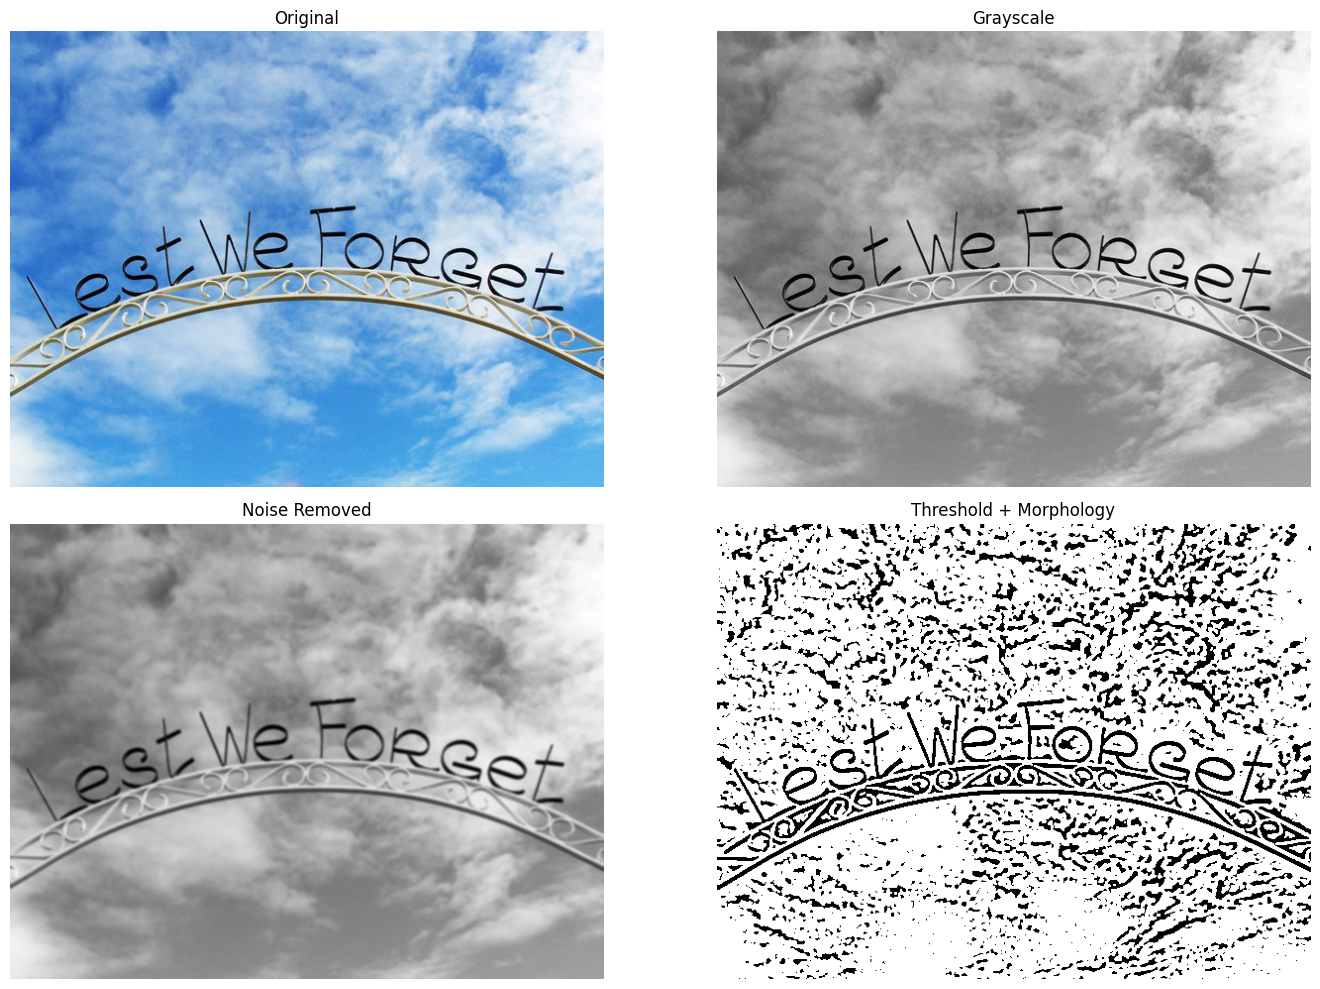

In [11]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(denoised, cmap="gray")
plt.title("Noise Removed")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(processed, cmap="gray")
plt.title("Threshold + Morphology")
plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
import pytesseract

print(
    pytesseract.image_to_string(processed)
)

In [13]:
extracted_text = pytesseract.image_to_string(
    processed,
    config="--psm 6"
)

print("===== EXTRACTED TEXT =====\n")
print(extracted_text)

===== EXTRACTED TEXT =====

ER ete ee OEE Lae UZ
ESA ee RM ae SM kg ee, feh ee F '
nee 2 Spt ie! Se ee 8 pee
ne re ein VS “~ re Me LS ae See
PR Re ae ap Nt eA a
“yp & eo bert goalie ae IM a, 4 at
Vee a ieee, 9 set Gee te
SpE ee Sa SOP EPS
a Le Een at che ES ERIS 8
OS Re a af oe patel Site
ee nT RUN peat oe Se eas
RL SR Bag Gen heen NTE CONT
wig Dye te oe Meta, PA
va AL bfeneeee SP aS
Se WEZROK QS ri
EN Ny ars Ft!
Wes EFI SC eZ
NS LOE OO PTA Sapa Pe SOS
a Ta GE SS
LO Soars eae
PCE ete LAMEE Sou yee Beane
RS TIRASE OnE ch Ra Ser
SORTASE oT beets, Bf Se
PPS Be ON MO gp AOE TE
Te EE RTE
nt ott af. bee _



In [14]:
original_text = pytesseract.image_to_string(
    image,
    config="--psm 6"
)

print("===== OCR WITHOUT PREPROCESSING =====\n")
print(original_text)

===== OCR WITHOUT PREPROCESSING =====

\Ne Fo
ee



In [15]:
processed_text = pytesseract.image_to_string(
    processed,
    config="--psm 6"
)

print("===== OCR WITH PREPROCESSING =====\n")
print(processed_text)

===== OCR WITH PREPROCESSING =====

ER ete ee OEE Lae UZ
ESA ee RM ae SM kg ee, feh ee F '
nee 2 Spt ie! Se ee 8 pee
ne re ein VS “~ re Me LS ae See
PR Re ae ap Nt eA a
“yp & eo bert goalie ae IM a, 4 at
Vee a ieee, 9 set Gee te
SpE ee Sa SOP EPS
a Le Een at che ES ERIS 8
OS Re a af oe patel Site
ee nT RUN peat oe Se eas
RL SR Bag Gen heen NTE CONT
wig Dye te oe Meta, PA
va AL bfeneeee SP aS
Se WEZROK QS ri
EN Ny ars Ft!
Wes EFI SC eZ
NS LOE OO PTA Sapa Pe SOS
a Ta GE SS
LO Soars eae
PCE ete LAMEE Sou yee Beane
RS TIRASE OnE ch Ra Ser
SORTASE oT beets, Bf Se
PPS Be ON MO gp AOE TE
Te EE RTE
nt ott af. bee _



In [16]:
import re

clean_text = re.sub(
    r'\n+',
    '\n',
    processed_text
)

clean_text = re.sub(
    r'[ \t]+',
    ' ',
    clean_text
)

clean_text = clean_text.strip()

print(clean_text)

ER ete ee OEE Lae UZ
ESA ee RM ae SM kg ee, feh ee F '
nee 2 Spt ie! Se ee 8 pee
ne re ein VS “~ re Me LS ae See
PR Re ae ap Nt eA a
“yp & eo bert goalie ae IM a, 4 at
Vee a ieee, 9 set Gee te
SpE ee Sa SOP EPS
a Le Een at che ES ERIS 8
OS Re a af oe patel Site
ee nT RUN peat oe Se eas
RL SR Bag Gen heen NTE CONT
wig Dye te oe Meta, PA
va AL bfeneeee SP aS
Se WEZROK QS ri
EN Ny ars Ft!
Wes EFI SC eZ
NS LOE OO PTA Sapa Pe SOS
a Ta GE SS
LO Soars eae
PCE ete LAMEE Sou yee Beane
RS TIRASE OnE ch Ra Ser
SORTASE oT beets, Bf Se
PPS Be ON MO gp AOE TE
Te EE RTE
nt ott af. bee _


In [17]:
output_file = "/content/extracted_document.txt"

with open(
    output_file,
    "w",
    encoding="utf-8"
) as f:
    f.write(clean_text)

print("Text saved successfully!")
print(output_file)

Text saved successfully!
/content/extracted_document.txt


In [18]:
data = pytesseract.image_to_data(
    processed,
    config="--psm 6",
    output_type=pytesseract.Output.DATAFRAME
)

data = data.dropna()

data = data[
    data["text"].astype(str).str.strip() != ""
]

print(data[[
    "text",
    "conf"
]].head(20))

   text  conf
4    ER     7
5   ete    38
6    ee    37
7   OEE    21
8   Lae    48
9    UZ    37
11  ESA     0
12   ee     0
13   RM    20
14   ae    24
15   SM    11
16   kg    20
17  ee,    34
18  feh     0
19   ee     0
20    F     0
21    '     5
23  nee    42
24    2    42
25  Spt    13


In [19]:
high_confidence = data[
    data["conf"] >= 60
]

validated_text = " ".join(
    high_confidence["text"].astype(str)
)

print("===== VALIDATED TEXT =====\n")
print(validated_text)

===== VALIDATED TEXT =====

NS ete


In [20]:
original_data = pytesseract.image_to_data(
    image,
    config="--psm 6",
    output_type=pytesseract.Output.DATAFRAME
)

original_data = original_data.dropna()

original_data = original_data[
    original_data["text"].astype(str).str.strip() != ""
]

original_confidence = original_data["conf"].mean()

processed_confidence = data["conf"].mean()

print(
    "Original Image OCR Confidence:",
    round(original_confidence, 2)
)

print(
    "Preprocessed Image OCR Confidence:",
    round(processed_confidence, 2)
)

Original Image OCR Confidence: 70.33
Preprocessed Image OCR Confidence: 21.61


In [21]:
import pandas as pd

comparison = pd.DataFrame({
    "Method": [
        "OCR without preprocessing",
        "OCR with preprocessing"
    ],

    "Average Confidence": [
        original_confidence,
        processed_confidence
    ],

    "Characters Extracted": [
        len(original_text),
        len(processed_text)
    ]
})

comparison

,Method,Average Confidence,Characters Extracted
0,OCR without preprocessing,70.333333,11
1,OCR with preprocessing,21.611111,580


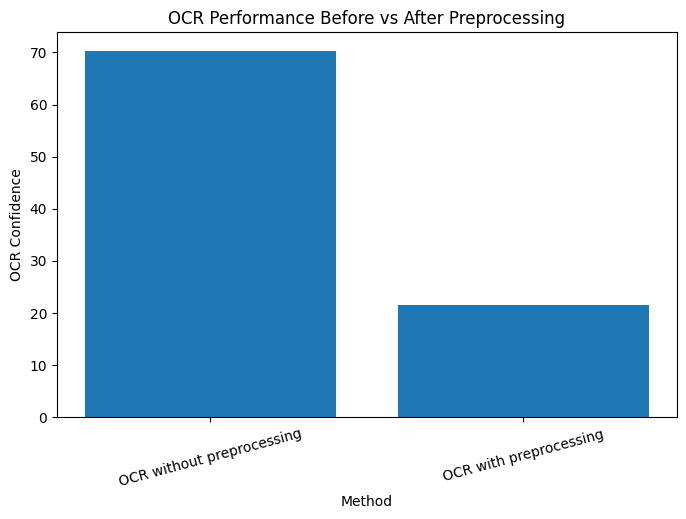

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Method"],
    comparison["Average Confidence"]
)

plt.ylabel("OCR Confidence")
plt.xlabel("Method")
plt.title("OCR Performance Before vs After Preprocessing")

plt.xticks(rotation=15)

plt.show()